# Time evolution

## DH vs En

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

C = 1
a = 1 
nu = 10
B = 1/2
alp =1e-2
N = 50
lam = 0.0001229769715723502

H = HxDHLong(N,C,a,nu,B,alp)
eigvals,_ = np.linalg.eigh(H)
idx = np.argsort((eigvals))
eigvals = eigvals[idx]
t_approx = np.pi/np.abs(eigvals[1]-eigvals[2])
t_vals = np.linspace(0,3*t_approx, int(5 * 1e3))

F_dh_t = F_vs_Tvals(HxDHLong, t_vals,N, C, a, nu, B, alp)
erg_dh_t = Avg_erg_vs_Tvals(HxDHLong, t_vals,N, C, a, nu, B, alp)
erg_eng_t = Avg_erg_vs_Tvals_En(lam,t_vals,N, C, a, nu, B, alp)

fig, ax = plt.subplots(2, 1,sharex=True,figsize=(15, 10))

fig.supxlabel(r"$t$")
fig.supylabel(r"$\langle\mathcal{E}\rangle$")

ax[0].plot(t_vals,F_dh_t, label="Fidel",color='r',)
ax[0].plot(t_vals,erg_dh_t, label="ergotropy",color='b',)
# ax[0].plot(t_vals,amp_dh_t, label="transfer amp",color='m',)

# ax[1].plot(t_vals,(-1j *np.sin(lam*t_vals/2))**(N-1), label="fidelity",color='r',)
ax[1].plot(t_vals,erg_eng_t, label="fidel",color='b',)
ax[1].plot(t_vals,np.abs((-1j *np.sin(lam*t_vals/2))**(N-1))**2/6+np.abs((-1j *np.sin(lam*t_vals/2))**(N-1))/3+1/2, label="transfer amp",color='m',)

ax[0].set_title(f"Double Hole")
ax[1].set_title(f"Engineered")
ax[0].legend()
ax[1].legend()

ax[0].set_ylim(0-1e-2,1)
ax[1].set_ylim(0-1e-2,1)
plt.xlim(0,np.max(t_vals))

# plt.savefig("Effo_heat_DH.png")
plt.tight_layout()
done()

## Ergotropy and its contribution

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

# for i in np.arange(0, 190, 10):
for i in range(90,92):
  C = 1
  a = 1 
  nu = 100
  B = 1
  p=0.5
  alp = 1e-2
  N = 50
  Th = np.deg2rad(i)
  Ph = np.deg2rad(30)

  E_in = B * (2 * np.sin(Th/2)**2-1+np.sqrt(1-4*p*(1-p)*np.sin(Th)**2 * np.cos(Ph)**2))

  t_approx,_,_ = tmax_DH_for_N(N,C,a,nu,B,alp)
  t_vals = np.linspace(0,3*t_approx, int(5 * 1e3))
  # t_vals = np.linspace(0,1e7, int(5 * 1e3))

  F_dh_t = F_vs_Tvals(HxxDHLong, t_vals,N, C, a, nu, B, alp)
  Erg_tot_t,Erg_pop_t,Erg_coh_t = Ergs_vs_Tvals_rhoC2(HxxDHLong,t_vals,N, C, a, nu, B, alp,p,Th,Ph)

  fig, ax = plt.subplots(2, 1,sharex=True,figsize=(15, 10))

  fig.supxlabel(r"$t$")
  fig.supylabel(r"$\langle\mathcal{E}\rangle$")

  ax[0].plot(t_vals,F_dh_t, label="Fidel",color='b',)
  ax[0].plot(t_vals,Erg_tot_t, label="ergotropy",color='r',)

  ax[1].plot(t_vals,Erg_coh_t, label="coherent Erg",color='b',)
  ax[1].plot(t_vals,Erg_pop_t, label="population Erg",color='m',)

  ax[0].set_title(rf"$\mathcal E \left[ \rho^{{(1)}}_{{C_2}} \right]= {E_in:.3f}$ $(p = {p}$, $\theta = {np.rad2deg(Th):.0f}$, $\phi = {np.rad2deg(Ph):.0f})$ at $B$={B:.1f}")
  ax[1].set_title(f"Contribution")
  ax[0].legend()
  ax[1].legend()

  plt.xlim(0,np.max(t_vals))

  plt.savefig(f"Hxx_Ergo_contribution_rhoC2_E={E_in:.3f}.png")
  plt.tight_layout()
done()

### XX stuff


Purity

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

# for i in np.arange(0, 190, 10):
for i in range(91,92):
  C = 1
  a = 1 
  nu = 10
  B = 1
  p=0.5
  alp = 1e-1
  N = 50
  Th = np.deg2rad(100)
  Ph = np.deg2rad(i)

  Erg_in = B * (2 * np.sin(Th/2)**2-1+np.sqrt(1-4*p*(1-p)*np.sin(Th)**2 * np.sin(Ph)**2))
  Erg_pop_in = 2*B * np.maximum(2*np.sin(Th/2)**2 - 1, 0)
  Erg_coh_in = Erg_in - Erg_pop_in
  purity_1 = 1 - 2 * det_rhoC3_1(1,p,Th,Ph)

  # t_approx,_,_ = tmax_DH_for_N(HxxDHLong,N,C,a,nu,B,alp)
  # t_vals = np.linspace(0,2*t_approx, int(5 * 1e3))
  t_vals = np.linspace(0,250, int(5 * 1e4))

  Erg_tot_t,Erg_pop_t,Erg_coh_t = Ergs_vs_Tvals_rhoC3(HxxDHLong,t_vals,N, C, a, nu, B, alp,p,Th,Ph)
  purity_N_t = purity_vs_Tvals_rhoC3(HxxDHLong,t_vals,N, C, a, nu, B, alp,p,Th,Ph)
    

  fig, ax = plt.subplots(3, 1,sharex=True,figsize=(15, 15))

  fig.supxlabel(r"$t$")

  ax[0].plot(t_vals,Erg_tot_t, label="ergotropy",color='m',)

  ax[1].plot(t_vals,Erg_coh_t, label="coherent Erg",color='r',)
  ax[1].plot(t_vals,Erg_pop_t, label="population Erg",color='b',)
  
  ax[2].plot(t_vals,purity_N_t,color='k',)

  ax[0].set_title(rf"$\mathcal E \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_in:.3f}$ $(p = {p}$, $\theta = {np.rad2deg(Th):.0f}$, $\phi = {np.rad2deg(Ph):.0f})$ at $B$={B:.1f}")
  ax[1].set_title(rf"Contribution, where $\mathcal{{E}}_\mathrm{{pop}} \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_pop_in:.3f}$ and $\mathcal{{ E}}_\mathrm{{coh}} \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_coh_in:.3f}$")
  ax[2].set_title(f"Purity evolution, with $\\mathrm{{Tr}}\\left[(\\rho^{{(1)}}_{{C_3}})^2\\right] = {purity_1:.3f}$")
  ax[1].legend()

  plt.xlim(np.min(t_vals),np.max(t_vals))

  plt.savefig(f"Hxx_Ergo_contribution_rhoC3_Phi={np.rad2deg(Ph):.0f}_E={Erg_in:.3f}.png")
  plt.tight_layout()
  plt.close(fig)
done()

Delta Puritu

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

for i in np.arange(0, 190, 10):
# for i in range(91,92):
  C = 1
  a = 1 
  nu = 10
  B = 1
  p=0.5
  alp = 1e-1
  N = 50
  Th = np.deg2rad(100)
  Ph = np.deg2rad(i)

  Erg_in = B * (2 * np.sin(Th/2)**2-1+np.sqrt(1-4*p*(1-p)*np.sin(Th)**2 * np.sin(Ph)**2))
  Erg_pop_in = 2*B * np.maximum(2*np.sin(Th/2)**2 - 1, 0)
  Erg_coh_in = Erg_in - Erg_pop_in
  purity_1 = 1 - 2 * det_rhoC3_1(1,p,Th,Ph)

  # t_approx,_,_ = tmax_DH_for_N(HxxDHLong,N,C,a,nu,B,alp)
  # t_vals = np.linspace(0,2*t_approx, int(5 * 1e3))
  t_vals = np.linspace(0,250, int(5 * 1e4))

  Erg_tot_t,Erg_pop_t,Erg_coh_t = Ergs_vs_Tvals_rhoC3(HxxDHLong,t_vals,N, C, a, nu, B, alp,p,Th,Ph)
  # purity_N_t = purity_vs_Tvals_rhoC3(HxxDHLong,t_vals,N, C, a, nu, B, alp,p,Th,Ph)
  purity_N_t = delta_purity_vs_Tvals_rhoC3(HxxDHLong,t_vals,N, C, a, nu, B, alp,p,Th,Ph)
    

  fig, ax = plt.subplots(3, 1,sharex=True,figsize=(15, 15))

  fig.supxlabel(r"$t$")
  ax[2].axhline(y=0, linestyle='--',color='purple')
  ax[0].plot(t_vals,Erg_tot_t, label="ergotropy",color='m',)

  ax[1].plot(t_vals,Erg_coh_t, label="coherent Erg",color='r',)
  ax[1].plot(t_vals,Erg_pop_t, label="population Erg",color='b',)
  
  ax[2].plot(t_vals,purity_N_t,color='k',)

  ax[0].set_title(rf"$\mathcal E \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_in:.3f}$ $(p = {p}$, $\theta = {np.rad2deg(Th):.0f}$, $\phi = {np.rad2deg(Ph):.0f})$ at $B$={B:.1f}")
  ax[1].set_title(rf"Contribution, where $\mathcal{{E}}_\mathrm{{pop}} \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_pop_in:.3f}$ and $\mathcal{{ E}}_\mathrm{{coh}} \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_coh_in:.3f}$")
  ax[2].set_title(f"Purity evolution, with $\\mathrm{{Tr}}\\left[(\\rho^{{(1)}}_{{C_3}})^2\\right] = {purity_1:.3f}$")
  ax[1].legend()

  plt.xlim(np.min(t_vals),np.max(t_vals))

  plt.savefig(f"Hxx_Ergo_contribution_rhoC3_Phi={np.rad2deg(Ph):.0f}_E={Erg_in:.3f}.png")
  plt.tight_layout()
  plt.close(fig)
done()

## Efficiency and its contribution

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

for i in np.arange(0, 190, 10):
# for i in range(91,92):
  C = 1
  a = 1 
  nu = 10
  B = 1
  p=0.5
  alp =1e-2
  N = 50
  Th = np.deg2rad(i)
  Ph = np.deg2rad(30)

  E_in = B * (2 * np.sin(Th/2)**2-1+np.sqrt(1-4*p*(1-p)*np.sin(Th)**2 * np.cos(Ph)**2))

  H = HxDHLong(N,C,a,nu,B,alp)
  eigvals,_ = np.linalg.eigh(H)
  idx = np.argsort((eigvals))
  eigvals = eigvals[idx]
  t_approx = np.pi/np.abs(eigvals[1]-eigvals[2])
  t_vals = np.linspace(0,3*t_approx, int(5 * 1e3))

  F_dh_t = F_vs_Tvals(HxxDHLong, t_vals,N, C, a, nu, B, alp)
  Erg_tot_t,Erg_pop_t,Erg_coh_t = Effs_vs_Tvals_rhoC2(HxDHLong,t_vals,N, C, a, nu, B, alp,p,Th,Ph)

  fig, ax = plt.subplots(2, 1,sharex=True,figsize=(15, 10))

  fig.supxlabel(r"$t$")
  fig.supylabel(r"$\eta$")

  ax[0].plot(t_vals,F_dh_t, label="Fidel",color='b',)
  ax[0].plot(t_vals,Erg_tot_t,color='r',)

  ax[1].plot(t_vals,Erg_coh_t, label="coherent Erg",color='b',)
  ax[1].plot(t_vals,Erg_pop_t, label="population Erg",color='m',)

  ax[0].set_title(rf"$\mathcal E \left[ \rho^{{(1)}}_{{C_2}} \right]= {E_in:.3f}$ $(p = {p}$, $\theta = {np.rad2deg(Th):.0f}$, $\phi = {np.rad2deg(Ph):.0f})$ at $B$={B:.1f}")
  ax[1].set_title(f"Contribution")
  ax[0].legend()
  ax[1].legend()

  plt.xlim(0,np.max(t_vals))

  plt.savefig(f"Full_Eff_contribution_rhoC2_E={E_in:.3f}.png")
  plt.tight_layout()
done()

## Max fidelity time for double hole

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

N_vals = np.arange(3, 100)
# alp_vals = np.logspace(-5, -1, 20)
alp_vals = np.append(0, np.logspace(-5, -1, 4))
# alp_vals = [0]
alp = 4e-2
C = 1
a = 1
# nu = 55
nu = [10]
B = 1

for nu in nu:
  t_vals = []
  t_vals_r = []
  k1_vals = []
  k2_vals = []
  F_max = []
  F_max_r = []
  for N in N_vals:


      t_max, k1, k2 = tmax_DH_for_N(HxxDHLong,N, C, a, nu, B, alp)
      # t_vals_F = t_max
      # t_vals_F = np.linspace(0*t_max,1e6,5000)
      # t_max = 30000/2 
      # t_vals_F = np.linspace(0*t_max,2*t_max,5000)
      # F = F_vs_Tvals(HxxDHLong, t_vals_F,N, C, a, nu, B, alp)

      t_vals.append(t_max)
      k1_vals.append(k1)
      k2_vals.append(k2)
      F_max.append(np.max(F))

      print(N)

  fig, ax = plt.subplots(2, 1, sharex=True, figsize=(15, 15))

  ax[0].plot(N_vals, t_vals)
  ax[0].set_ylabel(r"$t_{\mathrm{approx}}$")
  ax[0].set_title(rf"$t_\mathrm{{max}}$ for $\alpha={alp:.0e}$")
  ax[0].legend()

  ax[1].scatter(N_vals, k1_vals, label=r"$k_1$",marker="D",color="k",facecolor="none")
  ax[1].scatter(N_vals, k2_vals, label=r"$k_2$",marker="D",color="k",facecolor="none")
  ax[1].set_xlabel(r"$N$")
  ax[1].set_ylabel("Eigenstate index")

  # ax[2].plot(N_vals, F_max,label='approx time')
  # ax[2].plot(N_vals, F_max_r,label='max time')
  # ax[2].set_ylabel(r"$F_{\mathrm{max}}$")
  # ax[2].legend()
  
  plt.tight_layout()
  plt.savefig(f"t_max_nu{nu:.0f}_nu{alp:.3f}.png")
  # plt.savefig(f"t_max_alp{alp:.4f}.png")
done()

# Max Ergotropy vs N

## compare DH vs full

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

C = 1
a = 1
nu = 10
B = 1
alp =0.1
t_vals = np.linspace(0,30000, int(5 * 1e5))

N_vals = np.arange(2,10)

E_full = Avg_erg_vsN(HxLong,t_vals,N_vals, C, a, nu, B, alp)
E_dh = Avg_erg_vsN(HxDHLong,t_vals,N_vals, C, a, nu, B, alp)

plt.figure(figsize=(10, 6))
plt.xlabel(r'$N$')
plt.ylabel(r'$\langle\mathcal{E}\rangle_{m}$')

plt.scatter(N_vals,E_full, label=rf"Complete", marker="D",facecolor="none",color="black")
plt.plot(N_vals, E_dh, label=rf"Double-hole")

# plt.ylim(0.9 - 1e-2,1 + 1e-2)
plt.legend()
plt.savefig("Ergo_vs_N_EnAlt.png")

done()

## population and coherence contribution

### testing stuff

In [ ]:
# np.set_printoptions(precision=3, suppress=True)
import functions
import importlib

importlib.reload(functions)
from functions import *

N=10
C=1
a=1
nu=100
B=1
alph=.1

print(HxxDHLong(N, C, a, nu, B, alph))

### actual function

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

# for i in range(91,92):
for i in np.arange(0, 90, 10):
  C = 1
  a = 1
  nu = 10
  B = 1
  alp =1
  p = 0
  Th = np.deg2rad(i)
  # Th = i
  Ph = np.deg2rad(0)
  t_vals = np.linspace(0,4000, int(5 * 1e4))

  N_vals = np.arange(2,100)
      
  max_Erg_tot_all, max_Erg_pop_all, max_Erg_coh_all = Ergs_rhoC2_vs_N(HxxDHLong, t_vals,N_vals, C, a, nu, B, alp,p, Th, Ph)
  E_in = B * (2 * np.sin(Th/2)**2-1+np.sqrt(1-4*p*(1-p)*np.sin(Th)**2 * np.cos(Ph)**2))

  fig, ax = plt.subplots(2, 1,sharex=True,figsize=(15, 10))

  ax[0].plot(N_vals, max_Erg_tot_all, )
  ax[1].plot(N_vals, max_Erg_pop_all, label=rf"Erg pop",color='r',)
  ax[1].plot(N_vals, max_Erg_coh_all, label=rf"Erg coh",color='b',)

  ax[0].set_title(rf"Max $\mathcal E \left[ \rho^{{(N)}}_{{C_2}} \right]$ with $\mathcal E \left[ \rho^{{(1)}}_{{C_2}} \right]= {E_in:.3f}$ $(p = {p}$, $\theta = {np.rad2deg(Th):.0f}$, $\phi = {np.rad2deg(Ph):.0f})$ at $B$={B:.1f}")
  ax[1].set_title(f"Contribution")

  ax[0].set_ylabel("$\mathcal{ E}$")
  ax[1].set_ylabel("$\mathcal{ E}$")
  ax[1].set_xlabel("$N$")

  ax[1].legend()

  plt.savefig(f"Hxxx_Ergo_contribution_rhoC2_E={E_in:.3f}.png")
  plt.tight_layout()

done()

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

# for i in range(91,92):
for i in np.arange(0, 190, 10):
  C = 1
  a = 1
  nu = 10
  B = 1
  alp =0.1
  p = 0.5
  Th = np.deg2rad(i)
  Ph = np.deg2rad(30)
  t_vals = np.linspace(0,100/4, int(5 * 1e5))

  N_vals = np.arange(2,100)
      
  max_Erg_tot_all, max_Erg_pop_all, max_Erg_coh_all = Ergs_rhoC2_vs_N(HxLong, t_vals,N_vals, C, a, nu, B, alp,p, Th, Ph)
  E_in = B * (2 * np.sin(Th/2)**2-1+np.sqrt(1-4*p*(1-p)*np.sin(Th)**2 * np.cos(Ph)**2))

  fig, ax = plt.subplots(2, 1,sharex=True,figsize=(15, 10))

  ax[0].plot(N_vals, max_Erg_tot_all, )
  ax[1].plot(N_vals, max_Erg_pop_all, label=rf"Erg pop",color='r',)
  ax[1].plot(N_vals, max_Erg_coh_all, label=rf"Erg coh",color='b',)

  ax[0].set_title(rf"Max $\mathcal E \left[ \rho^{{(N)}}_{{C_2}} \right]$ with $\mathcal E \left[ \rho^{{(1)}}_{{C_2}} \right]= {E_in:.3f}$ $(p = {p}$, $\theta = {np.rad2deg(Th):.0f}$, $\phi = {np.rad2deg(Ph):.0f})$ at $B$={B:.1f}")
  ax[1].set_title(f"Contribution")

  ax[0].set_ylabel("$\mathcal{ E}$")
  ax[1].set_ylabel("$\mathcal{ E}$")
  ax[1].set_xlabel("$N$")

  ax[1].legend()

  plt.savefig(f"Full_Ergo_contribution_FullHx_rhoC2_E={E_in:.3f}.png")
  plt.tight_layout()

done()

### Paper, classic, dual hole comparation

#### with label

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

C = 1
a = 1
nu = 10
B = 1
alp = 0.1306335127025405
# alp = 0.1510371854370874
# alp = 1
p = 0.5
t_vals = np.linspace(0,1000, int(5 * 1e3))
N_vals = np.arange(2,101)

for i in np.arange(90, 190, 10):
# for i in [60,90,120,180]:
# for i in [100]:
  Th = np.deg2rad(120)
  Ph = np.deg2rad(100)
  Erg_in = B * (2 * np.sin(Th/2)**2-1+np.sqrt(1-4*p*(1-p)*np.sin(Th)**2 * np.sin(Ph)**2))
  Erg_pop_in = 2*B * np.maximum(2*np.sin(Th/2)**2 - 1, 0)
  Erg_coh_in = Erg_in - Erg_pop_in

  fn_cl = np.sqrt(2)-1
  Erg_tot_cl = B * (2 * np.sin(Th/2)**2*fn_cl**2-1+np.sqrt(1-4*fn_cl**2*(p*(1-p)*np.sin(Th)**2 * np.sin(Ph)**2+ np.sin(Th/2)**4*(1-fn_cl**2) ) ))

  max_Erg_tot_all, max_Erg_pop_all, max_Erg_coh_all = Ergs_rhoC3_vs_N(HxxDHLong, t_vals,N_vals, C, a, nu, B, alp,p, Th, Ph)

  fig, ax = plt.subplots(2, 1,sharex=True,figsize=(15, 10))

  ax[0].plot(N_vals, max_Erg_tot_all, )
  ax[0].axhline(y=Erg_tot_cl, linestyle='--')
  ax[1].plot(N_vals, max_Erg_pop_all, label=rf"Erg pop",color='r',)
  ax[1].plot(N_vals, max_Erg_coh_all, label=rf"Erg coh",color='b',)

  ax[0].set_title(rf"Max $\mathcal E \left[ \rho^{{(N)}}_{{C_2}} \right]$ with $\mathcal E \left[ \rho^{{(1)}}_{{C_2}} \right]= {Erg_in:.3f}$ $(p = {p}$, $\theta = {np.rad2deg(Th):.0f}$, $\phi = {np.rad2deg(Ph):.0f})$ at $B$={B:.1f}")
  ax[1].set_title(f"Contribution")

  ax[0].annotate(
      fr"$\mathcal{{E}}_\mathrm{{max}}\left[\rho^{{(N)}}_{{\mathrm{{cl}}}}\right]"
      fr"={Erg_tot_cl:.3f}$",
      xy=(0.98, Erg_tot_cl),
      xycoords=('axes fraction', 'data'),
      xytext=(-5, 5),
      textcoords='offset points',
      ha='right',
      va='bottom'
  )

  fig.supylabel(r"$\mathcal{ E}_\mathrm{max} \left[ \rho^{{(N)}}_{{C_2}} \right]$")
  ax[1].set_xlabel("$N$")

  ax[1].legend()

  plt.tight_layout()
  plt.savefig(f"Ergo_compare_E={Erg_in:.3f}.png")
  plt.close(fig)

done()

#### without

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

C = 1
a = 1
nu = 10
B = 1
alp = 0.1306335127025405
# alp = 1
p = 1
Ph = np.deg2rad(0)
t_vals = np.linspace(0,1000, int(5 * 1e3))
N_vals = np.arange(2,101)


for i in [60,90,120,180]:
# for i in [120]:
  Th = np.deg2rad(i)
  Erg_in = B * (2 * np.sin(Th/2)**2-1+np.sqrt(1-4*p*(1-p)*np.sin(Th)**2 * np.sin(Ph)**2))
  Erg_pop_in = 2*B * np.maximum(2*np.sin(Th/2)**2 - 1, 0)
  Erg_coh_in = Erg_in - Erg_pop_in

  fn_cl = np.sqrt(2)-1
  Erg_tot_cl = np.abs(B * (2 * np.sin(Th/2)**2*fn_cl**2-1+np.sqrt(1-4*fn_cl**2*(p*(1-p)*np.sin(Th)**2 * np.sin(Ph)**2+ np.sin(Th/2)**4*(1-fn_cl**2) ) )))

  max_Erg_tot_all, max_Erg_pop_all, max_Erg_coh_all = Ergs_rhoC3_vs_N(HxxDHLong, t_vals,N_vals, C, a, nu, B, alp,p, Th, Ph)

  fig, ax = plt.subplots(2, 1,sharex=True,figsize=(3.4, 2.4),    layout='constrained')

  ax[0].plot(N_vals, max_Erg_tot_all, color='purple')
  ax[0].axhline(y=Erg_tot_cl, linestyle='--',color='purple')
  ax[1].plot(N_vals, max_Erg_pop_all, label=rf"Erg pop",color='r',)
  ax[1].plot(N_vals, max_Erg_coh_all, label=rf"Erg coh",color='b',)


  ax[0].annotate(
      fr"$\mathcal{{E}}_\mathrm{{max}}^\mathrm{{cl}}"
      fr"={Erg_tot_cl:.3f}$",
      xy=(0.98, Erg_tot_cl),
      xycoords=('axes fraction', 'data'),
      xytext=(-5, 5),
      textcoords='offset points',
      ha='right',
      va='bottom'
  )
  ax[0].text(1.075, 0.5, '(a)', transform=ax[0].transAxes,
           va='center', ha='right')
  ax[1].text(1.075, 0.5, '(b)', transform=ax[1].transAxes,
           va='center', ha='right')

  ax[1].set_xlim(2, 100)
  ax[0].text(0, 1.02,r"$\mathcal{E}_{\mathrm{max}}$",transform=ax[0].transAxes,ha="center",va="bottom"  )
  ax[1].text(1.02, 0,r"$N$",transform=ax[1].transAxes,ha="center",va="center"  )


  plt.savefig(f"Ergo_compaare_classic_Erg={Erg_in:.1f}.png",dpi=300)
  plt.close(fig)

done()

### Efficiency

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

# for i in range(91,92):
for i in np.arange(110, 190, 10):
  C = 1
  a = 1
  nu = 10
  B = 1
  alp =0.1
  p = 0.5
  Th = np.deg2rad(i)
  Ph = np.deg2rad(30)
  t_vals = np.linspace(0,4000, int(5 * 1e1))

  N_vals = np.arange(2,5)
      
  max_Eff_tot_all, max_Eff_pop_all, max_Eff_coh_all = Ergs_rhoC3_vs_N(HxLong, t_vals,N_vals, C, a, nu, B, alp,p, Th, Ph)
  E_in = B * (2 * np.sin(Th/2)**2-1+np.sqrt(1-4*p*(1-p)*np.sin(Th)**2 * np.cos(Ph)**2))

  fig, ax = plt.subplots(2, 1,sharex=True,figsize=(15, 10))

  ax[0].plot(N_vals, max_Eff_tot_all, )
  ax[1].plot(N_vals, max_Eff_pop_all, label=rf"Eff pop",color='r',)
  ax[1].plot(N_vals, max_Eff_coh_all, label=rf"Eff coh",color='b',)

  ax[0].set_title(rf"Max $\mathcal E \left[ \rho^{{(N)}}_{{C_2}} \right]$ with $\mathcal E \left[ \rho^{{(1)}}_{{C_2}} \right]= {E_in:.3f}$ $(p = {p}$, $\theta = {np.rad2deg(Th):.0f}$, $\phi = {np.rad2deg(Ph):.0f})$ at $B$={B:.1f}")
  ax[1].set_title(f"Contribution")

  ax[0].set_ylabel("$\eta$")
  ax[1].set_ylabel("$\eta$")
  ax[1].set_xlabel("$N$")

  ax[1].legend()

  plt.savefig(f"Full_Effo_contribution_FullHx_rhoC2_E={E_in:.3f}.png")
  plt.tight_layout()

done()

## Fidelity or Ergo vs alpha

fidelity

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

alp_vals = np.linspace(1e-5,0.5,int(5*1e0))
N = [100]
C = 1
a = 1
nu_vals = [1, 2, 3, 5, 10]
B = 1
t_vals = np.linspace(0,1000, int(5 * 1e0))


fig_comb, ax_comb = plt.subplots(1, 1, sharex=True, figsize=(15, 15))

for nu in nu_vals:
  F_max = [
      np.max(amp_vs_N(HxxDHLong, t_vals, N, C, a, nu, B, alp))
      for alp in alp_vals
  ]
  F_max_arg = np.argmax(F_max)
  alp_max = alp_vals[F_max_arg]
  F_max_val = F_max[F_max_arg]
  
  fig, ax = plt.subplots(1, 1, sharex=True, figsize=(15, 15))

  ax.plot(alp_vals, F_max)
  ax.scatter(alp_max, F_max_val)
  ax.annotate(
      fr"$\alpha={alp_max:.3f}$",
      xy=(alp_max, F_max_val),
      xytext=(5, 5),
      textcoords="offset points"
  )
  ax_comb.annotate(
      fr"$\alpha={alp_max:.3f}$",
      xy=(alp_max, F_max_val),
      xytext=(5, 5),
      textcoords="offset points"
  )

  ax.set_xlabel(r"$\alpha$")
  ax.set_ylabel(r"$F_{\max}$")
  ax.set_title(fr"$\nu={nu}$")
  fig.tight_layout()
  fig.savefig(f"ampmax_nu{nu}.png", dpi=300)
  plt.close(fig)

  # Add the same curve to combined figure
  ax_comb.plot(alp_vals, F_max, label=fr"$\nu={nu}$")
  
ax_comb.set_xlabel(r"$\alpha$")
ax_comb.set_ylabel(r"$F_{\max}$")
ax_comb.legend()
fig_comb.tight_layout()
fig_comb.savefig("amp_max_combined.png", dpi=300)
plt.close(fig_comb)
done()

ergo

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

alp_vals = np.linspace(1e-5,0.5,int(5*1e1))
N = [10]
C = 1
a = 1
nu_vals = [1,3,10]
B = 1
p=0.5
Th = np.deg2rad(100)
Ph = np.deg2rad(100)
t_vals = np.linspace(0,1000, int(5 * 1e1))

Erg_in = B * (2 * np.sin(Th/2)**2-1+np.sqrt(1-4*p*(1-p)*np.sin(Th)**2 * np.sin(Ph)**2))
Erg_pop_in = 2*B * np.maximum(2*np.sin(Th/2)**2 - 1, 0)
Erg_coh_in = Erg_in - Erg_pop_in

fig_comb, ax_comb = plt.subplots(1, 1, sharex=True, figsize=(15, 15))
for nu in nu_vals:
  Ergo_tot_max = []
  Ergo_pop_max = []
  Ergo_coh_max = []
  for alp in alp_vals:
        Ergo_tot, Ergo_pop, Ergo_coh = Ergs_rhoC3_vs_N(
            HxxDHLong, t_vals, N, C, a, nu, B, alp, p, Th, Ph
        )
        Ergo_tot_max.append(np.max(Ergo_tot))
        Ergo_pop_max.append(np.max(Ergo_pop))
        Ergo_coh_max.append(np.max(Ergo_coh))
  Ergo_tot_max_arg = np.argmax(Ergo_tot_max)
  Ergo_pop_max_arg = np.argmax(Ergo_pop_max)
  Ergo_coh_max_arg = np.argmax(Ergo_coh_max)
  alp_tot_max = alp_vals[Ergo_tot_max_arg]
  alp_pop_max = alp_vals[Ergo_pop_max_arg]
  alp_coh_max = alp_vals[Ergo_coh_max_arg]
  Ergo_tot_max_val = Ergo_tot_max[Ergo_tot_max_arg]
  Ergo_pop_max_val = Ergo_pop_max[Ergo_pop_max_arg]
  Ergo_coh_max_val = Ergo_coh_max[Ergo_coh_max_arg]
  
  fig, ax = plt.subplots(2, 1, sharex=True, figsize=(15, 15))

  ax[0].plot(alp_vals,Ergo_tot_max)
  ax[0].scatter(alp_tot_max, Ergo_tot_max_val)
  ax[0].annotate(
      fr"$\alpha={alp_tot_max}$",
      xy=(alp_tot_max, Ergo_tot_max_val),
      xytext=(5, 5),
      textcoords="offset points"
  )
  
  ax[1].plot(alp_vals,Ergo_pop_max, label="pop")
  ax[1].scatter(alp_pop_max, Ergo_pop_max_val)
  ax[1].annotate(
      fr"$\alpha={alp_pop_max}$",
      xy=(alp_pop_max, Ergo_pop_max_val),
      xytext=(5, 5),
      textcoords="offset points"
  )
  ax[1].plot(alp_vals,Ergo_coh_max, label="coh")
  ax[1].scatter(alp_coh_max, Ergo_coh_max_val)
  ax[1].annotate(
      fr"$\alpha={alp_coh_max}$",
      xy=(alp_coh_max, Ergo_coh_max_val),
      xytext=(5, 5),
      textcoords="offset points"
  )

  fig.supxlabel(r"$\alpha$")
  fig.supylabel(r"$\mathcal E \left[ \rho^{{(N)}}_{{C_3}} \right]$")
  ax[0].set_title(rf"$\mathcal E \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_in:.3f}$ $(p = {p}$, $\theta = {np.rad2deg(Th):.0f}$, $\phi = {np.rad2deg(Ph):.0f})$ at $\nu$={nu}")
  ax[1].set_title(rf"Contribution, where $\mathcal{{E}}_\mathrm{{pop}} \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_pop_in:.3f}$ and $\mathcal{{ E}}_\mathrm{{coh}} \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_coh_in:.3f}$")
  fig.tight_layout()
  fig.savefig(f"Fmax_nu{nu}.png", dpi=300)
  plt.close(fig)

  ax_comb.plot(alp_vals, Ergo_tot_max, label=fr"$\nu={nu}$")
  
ax_comb.set_xlabel(r"$\alpha$")
ax_comb.set_ylabel(r"$E_{\max}$")
ax_comb.legend()
fig_comb.tight_layout()
fig_comb.savefig("Fmax_combined.png", dpi=300)
plt.close(fig_comb)
done()

## Fidelity or Ergo vs nu

fidelity

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

alp_vals = [0.151037,0.475795,0.103828,0.226150]
N = [100]
C = 1
a = 1
nu_vals = np.linspace(1,10,int(5*10e0))
B = 1
t_vals = np.linspace(0,1000, int(5 * 1e0))


fig_comb, ax_comb = plt.subplots(1, 1, sharex=True, figsize=(15, 15))

for alp in alp_vals:
  F_max = [
      np.max(F_vs_N(HxxDHLong, t_vals, N, C, a, nu, B, alp))
      for nu in nu_vals
  ]
  F_max_arg = np.argmax(F_max)
  nu_max = nu_vals[F_max_arg]
  F_max_val = F_max[F_max_arg]
  
  fig, ax = plt.subplots(1, 1, sharex=True, figsize=(15, 15))

  ax.plot(nu_vals, F_max)
  ax.scatter(nu_max, F_max_val)
  ax.annotate(
      fr"$\nu={nu_max:.3f}$",
      xy=(nu_max, F_max_val),
      xytext=(5, 5),
      textcoords="offset points"
  )
  ax_comb.annotate(
      fr"$\nu={nu_max:.3f}$",
      xy=(nu_max, F_max_val),
      xytext=(5, 5),
      textcoords="offset points"
  )

  ax.set_xlabel(r"$\nu$")
  ax.set_ylabel(r"$F_{\max}$")
  ax.set_title(fr"$\alpha={alp}$")
  fig.tight_layout()
  fig.savefig(f"Fmax_alp{alp}.png", dpi=300)
  plt.close(fig)

  # Add the same curve to combined figure
  ax_comb.plot(nu_vals, F_max, label=fr"$\alpha={alp}$")
  
ax_comb.set_xlabel(r"$\nu$")
ax_comb.set_ylabel(r"$F_{\max}$")
ax_comb.legend()
fig_comb.tight_layout()
fig_comb.savefig("Fmax_combined.png", dpi=300)
plt.close(fig_comb)
done()

ergo

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

alp_vals = [0.151037,0.475795,0.103828,0.226150]
N = [10]
C = 1
a = 1
nu_vals = np.linspace(1,10,int(5*10e0))
B = 1
p=0.5
Th = np.deg2rad(100)
Ph = np.deg2rad(100)
t_vals = np.linspace(0,1000, int(5 * 1e1))

Erg_in = B * (2 * np.sin(Th/2)**2-1+np.sqrt(1-4*p*(1-p)*np.sin(Th)**2 * np.sin(Ph)**2))
Erg_pop_in = 2*B * np.maximum(2*np.sin(Th/2)**2 - 1, 0)
Erg_coh_in = Erg_in - Erg_pop_in

fig_comb, ax_comb = plt.subplots(1, 1, sharex=True, figsize=(15, 15))
for alp in alp_vals:
  Ergo_tot_max = []
  Ergo_pop_max = []
  Ergo_coh_max = []
  for nu in nu_vals:
        Ergo_tot, Ergo_pop, Ergo_coh = Ergs_rhoC3_vs_N(
            HxxDHLong, t_vals, N, C, a, nu, B, alp, p, Th, Ph
        )
        Ergo_tot_max.append(np.max(Ergo_tot))
        Ergo_pop_max.append(np.max(Ergo_pop))
        Ergo_coh_max.append(np.max(Ergo_coh))
  Ergo_tot_max_arg = np.argmax(Ergo_tot_max)
  Ergo_pop_max_arg = np.argmax(Ergo_pop_max)
  Ergo_coh_max_arg = np.argmax(Ergo_coh_max)
  nu_tot_max = nu_vals[Ergo_tot_max_arg]
  nu_pop_max = nu_vals[Ergo_pop_max_arg]
  nu_coh_max = nu_vals[Ergo_coh_max_arg]
  Ergo_tot_max_val = Ergo_tot_max[Ergo_tot_max_arg]
  Ergo_pop_max_val = Ergo_pop_max[Ergo_pop_max_arg]
  Ergo_coh_max_val = Ergo_coh_max[Ergo_coh_max_arg]
  
  fig, ax = plt.subplots(2, 1, sharex=True, figsize=(15, 15))

  ax[0].plot(nu_vals,Ergo_tot_max)
  ax[0].scatter(nu_tot_max, Ergo_tot_max_val)
  ax[0].annotate(
      fr"$\nu={nu_tot_max}$",
      xy=(nu_tot_max, Ergo_tot_max_val),
      xytext=(5, 5),
      textcoords="offset points"
  )
  
  ax[1].plot(nu_vals,Ergo_pop_max, label="pop")
  ax[1].scatter(nu_pop_max, Ergo_pop_max_val)
  ax[1].annotate(
      fr"$\nu={nu_pop_max}$",
      xy=(nu_pop_max, Ergo_pop_max_val),
      xytext=(5, 5),
      textcoords="offset points"
  )
  ax[1].plot(nu_vals,Ergo_coh_max, label="coh")
  ax[1].scatter(nu_coh_max, Ergo_coh_max_val)
  ax[1].annotate(
      fr"$\nu={nu_coh_max}$",
      xy=(nu_coh_max, Ergo_coh_max_val),
      xytext=(5, 5),
      textcoords="offset points"
  )

  fig.supxlabel(r"$\nu$")
  fig.supylabel(r"$\mathcal E \left[ \rho^{{(N)}}_{{C_3}} \right]$")
  ax[0].set_title(rf"$\mathcal E \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_in:.3f}$ $(p = {p}$, $\theta = {np.rad2deg(Th):.0f}$, $\phi = {np.rad2deg(Ph):.0f})$ at $\nu$={nu}")
  ax[1].set_title(rf"Contribution, where $\mathcal{{E}}_\mathrm{{pop}} \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_pop_in:.3f}$ and $\mathcal{{ E}}_\mathrm{{coh}} \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_coh_in:.3f}$")
  fig.tight_layout()
  fig.savefig(f"Emax_alp{alp}.png", dpi=300)
  plt.close(fig)

  ax_comb.plot(nu_vals, Ergo_tot_max, label=fr"$\nu={nu}$")
  
ax_comb.set_xlabel(r"$\nu$")
ax_comb.set_ylabel(r"$E_{\max}$")
ax_comb.legend()
fig_comb.tight_layout()
fig_comb.savefig("Emax_combined.png", dpi=300)
plt.close(fig_comb)
done()

# Non coupling stuff

## Heatmaps

### First site ergotropy

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

theta_vals = np.linspace(0, 1 * np.pi, 500)
H = HxDHLong(N,C,a,nu,B,alp)
eigvals,_ = np.linalg.eigh(H)
idx = np.argsort((eigvals))
eigvals = eigvals[idx]
t_approx = np.pi/np.abs(eigvals[1]-eigvals[2])

t_vals = np.linspace(0,3*t_approx, int(5 * 1e3))
Theta, T = np.meshgrid(theta_vals, t_vals)

s = np.sin(Theta / 2)**2

# q = (-1j * np.sin(lam * T / 2)**(N - 1))**2

q = amp_vs_Tvals(HxDHLong,t_vals,N, C, a, nu, B, alp)
q = q[:, None]  

Erg = (2*q*s- 1+ np.sqrt(1 + 4 * s**2 * q * (q - 1)))

fig, ax = plt.subplots(figsize=(15, 10))

im = ax.pcolormesh(
    T,
    Theta,
    Erg,
    shading='auto'
)

fig.colorbar(im, ax=ax, label=r'$\mathcal{E}_{\mathrm{coh}}$')

ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\theta$')

plt.tight_layout()
# plt.savefig("Ergo_heat_DH.png")
plt.show()

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

theta_vals = np.linspace(0, 1 * np.pi, 500)
phi_vals = np.linspace(0, 2 * np.pi, 1000)
B = 1
for i in np.arange(0, 0.6, 0.1):
    p = i

    Th, Ph = np.meshgrid(theta_vals, phi_vals)

    st = np.sin(Th)**2
    sp = np.sin(Ph)**2
    ct = np.cos(Th)**2
    cp = np.cos(Ph)**2

    # Erg total rho C2
    # Erg = B * (2*np.sin(Th/2)**2- 1+ np.sqrt(1 + 4 * p * (1-p) * np.sin(Th)**2 * np.cos(Ph)**2))
    # Erg pop rho C2
    # Erg = B * (2*np.sin(Th/2)**2- 1)
    # Erg coh rho C2
    Erg = B * (1-2*np.sin(Th/2)**2+ np.sqrt(1 - 4 * p * (1-p) * np.sin(Th)**2 * np.cos(Ph)**2))
    # Erg total rho C3
    # Erg = B * (2*np.sin(Th/2)**2- 1+ np.sqrt(1 + 4 * p * (1-p) * np.sin(Th)**2 * np.sin(Ph)**2))

    fig, ax = plt.subplots(figsize=(15, 10))

    im = ax.pcolormesh(
        Th,
        Ph,
        Erg,
        shading='auto'
    )

    fig.colorbar(im, ax=ax, label=r'$  \mathcal{E} \left[ \rho^{(1)}_{C_3} \right]  $')
    ax.set_title(rf'$\mathcal{{E}} \left[ \rho^{{(1)}}_{{C_3}} \right]  $ for $p={p:.1f}$')
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$\phi$')

    theta_ticks = np.arange(0, 5) * np.pi / 4
    theta_labels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

    phi_ticks = np.arange(0, 9) * np.pi / 4
    phi_labels = [
        r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$',
        r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$'
    ]

    ax.set_xticks(theta_ticks, theta_labels)
    ax.set_yticks(phi_ticks, phi_labels)

    plt.tight_layout()
    plt.savefig(f"Ergo_rhoC2_init_coh_p{p:.2f}_heat.png")
    plt.show()

done()

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

theta_vals = np.linspace(0, 1 * np.pi, 500)
phi_vals = np.linspace(0, 2 * np.pi, 4000)
B = 1
for i in np.arange(0, 0.6, 0.1):
    p = i

    Th, Ph = np.meshgrid(theta_vals, phi_vals)

    st = np.sin(Th)**2
    sp = np.sin(Ph)**2
    ct = np.cos(Th)**2
    cp = np.cos(Ph)**2

    # Erg total rho C2
    # Erg = B * (2*np.sin(Th/2)**2- 1+ np.sqrt(1 + 4 * p * (1-p) * np.sin(Th)**2 * np.cos(Ph)**2))
    
    # Erg pop rho C2
    # Erg = np.where(
    #     Th < np.pi/2,
    #     0,
    #     B * (2*np.sin(Th/2)**2 - 1)
    # )

    # Erg coh rho C2
    Erg = (
        B * (
            2*np.sin(Th/2)**2 - 1
            + np.sqrt(
                1 - 4*p*(1-p)
                * np.sin(Th)**2
                * np.cos(Ph)**2
            )
        )
        - np.where(
            Th < np.pi/2,
            0,
            B * (2*np.sin(Th/2)**2 - 1)
        )
    )
    


    fig, ax = plt.subplots(figsize=(15, 10))

    im = ax.pcolormesh(
        Th,
        Ph,
        Erg,
        shading='auto'
    )

    fig.colorbar(im, ax=ax, label=r'$  \mathcal{E} \left[ \rho^{(1)}_{C_3} \right]  $')
    ax.set_title(rf'$\mathcal{{E}} \left[ \rho^{{(1)}}_{{C_3}} \right]  $ for $p={p:.1f}$')
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$\phi$')

    theta_ticks = np.arange(0, 5) * np.pi / 4
    theta_labels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

    phi_ticks = np.arange(0, 9) * np.pi / 4
    phi_labels = [
        r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$',
        r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$'
    ]

    ax.set_xticks(theta_ticks, theta_labels)
    ax.set_yticks(phi_ticks, phi_labels)

    plt.tight_layout()
    plt.savefig(f"Ergo_rhoC2_init_coh_p{p:.2f}_heat.png")
    plt.show()

done()

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

theta_vals = np.linspace(0, 1 * np.pi, 500)
phi_vals = np.linspace(0, 2 * np.pi, 1000)
B = 1

# for fn in np.arange(0,1.1,0.1):
# for i in np.arange(0, 0.6, 0.1):
for i in [1,0.5,0.3]:
    p = i
    # p = 0
    Th, Ph = np.meshgrid(theta_vals, phi_vals)

    st = np.sin(Th)**2
    st2 = np.sin(Th/2)**2
    sp = np.sin(Ph)**2
    ct = np.cos(Th)**2
    cp = np.cos(Ph)**2

    Erg_pop = 2 * B * np.maximum(2*np.sin(Th/2)**2 - 1, 0)
    Erg = (
        B * (
            2*np.sin(Th/2)**2 - 1
            + np.sqrt(
                1 - 4*p*(1-p)
                * np.sin(Th)**2
                * np.cos(Ph)**2
            )
        )
        )
    Erg_coh = Erg - Erg_pop 

    fig, ax = plt.subplots(3,1, figsize=(15, 13),constrained_layout=True)

    vmin = Erg.min()
    vmax = Erg.max()

    im0 = ax[0].pcolormesh(Th,Ph,Erg,shading='auto',vmin=vmin,vmax=vmax )
    im1 = ax[1].pcolormesh(Th,Ph,Erg_pop,shading='auto',vmin=vmin,vmax=vmax)
    im2 = ax[2].pcolormesh(Th,Ph,Erg_coh,shading='auto',vmin=vmin,vmax=vmax)

    fig.colorbar(im0, ax=ax, label=r'$ \mathcal{E} \left[ \rho^{(1)}_{C_2} \right]  $')

    ax[0].set_title(rf'$\mathcal{{E}} \left[ \rho^{{(1)}}_{{C_2}} \right]  $ for $p={p:.1f}$')
    ax[1].set_title(rf'$\mathcal{{E}}_\mathrm{{pop}} \left[ \rho^{{(1)}}_{{C_2}} \right]  $')
    ax[2].set_title(rf'$\mathcal{{E}}_\mathrm{{coh}} \left[ \rho^{{(N1}}_{{C_2}} \right]  $')

    theta_ticks = np.arange(0, 5) * np.pi / 4
    theta_labels = [r'$0$', r'$\pi/4$',r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

    phi_ticks = np.arange(0, 9) * np.pi / 4
    phi_labels = [
        r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$',
        r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$'
    ]

    for i in range(3):
        ax[i].set_ylabel(r'$\phi$')
        ax[i].set_yticks(phi_ticks, phi_labels)
        ax[i].set_xticks(theta_ticks)

    ax[0].tick_params(axis='x', labelbottom=False)
    ax[1].tick_params(axis='x', labelbottom=False)

    ax[2].set_xlabel(r'$\theta$')
    ax[2].set_xticks(theta_ticks, theta_labels)

    # plt.tight_layout()
    plt.savefig(f"Ergo_rhoC2_1_contribution_p{p:.2f}.png")
    plt.close(fig)
done()

#### critica angle

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

fn = np.linspace(0, 1, 1000)

theta_c = 2 * np.arcsin(
    (1 / np.sqrt(2 * fn)).astype(complex)
)


fig, ax = plt.subplots(1, 1, figsize=(15, 8), constrained_layout=True)

ax.plot(fn, np.abs(theta_c),label=r'$|\theta_c|$')
ax.plot(fn, theta_c.real, label=r'$\mathrm{Re}(\theta_c)$')
ax.plot(fn, theta_c.imag, label=r'$\mathrm{Im}(\theta_c)$')
ax.legend()

ax.set_xlabel(r'$|f_N|^2$',)
ax.set_ylabel(r'$\theta_c$', )

ax.set_title(r"$\theta_c$ for $\mathcal E_\mathrm{pop}$ extend" )
ax.set_xlim(0, 1)
ax.set_ylim(0,1.5* np.pi)

ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.set_yticks(np.arange(0, 7) * np.pi / 4)
ax.set_yticklabels([
    r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$', r'$5\pi/4$', r'$3\pi/2$'
])

plt.savefig("Critical_angle_extend.png")
plt.show()

### Final site ergotropy

#### Total

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

theta_vals = np.linspace(0, 1 * np.pi, 500)
phi_vals = np.linspace(0, 2 * np.pi, 1000)
B = 1
for fn in np.arange(0,1.1,0.1):
#   for i in np.arange(0, 1.1, 0.1):
    # p = i
    p = 0
    Th, Ph = np.meshgrid(theta_vals, phi_vals)

    st = np.sin(Th)**2
    st2 = np.sin(Th/2)**2
    sp = np.sin(Ph)**2
    ct = np.cos(Th)**2
    cp = np.cos(Ph)**2
    q = fn
    
    Erg = (
            B * (
                2*q*np.sin(Th/2)**2 - 1
                + np.sqrt(
                    1 - 4*q*(p*(1-p)
                    * np.sin(Th)**2
                    * np.cos(Ph)**2 + np.sin(Th/2)**4*(1-q))
                )
            )
        )

    fig, ax = plt.subplots(figsize=(15, 10))

    im = ax.pcolormesh(
        Th,
        Ph,
        Erg,
        shading='auto'
    )

    fig.colorbar(im, ax=ax, label=r'$  \mathcal{E} \left[ \rho^{(1)}_{C_3} \right]  $')
    ax.set_title(rf'$\mathcal{{E}} \left[ \rho^{{(N)}}_{{C_2}} \right]  $ for $p={p:.1f}$ and $|f_N|^2={q:.1f}$')
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$\phi$')

    theta_ticks = np.arange(0, 5) * np.pi / 4
    theta_labels = [r'$0$', r'$\pi/4$',r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

    phi_ticks = np.arange(0, 9) * np.pi / 4
    phi_labels = [
        r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$',
        r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$'
    ]

    ax.set_xticks(theta_ticks, theta_labels)
    ax.set_yticks(phi_ticks, phi_labels)

    plt.tight_layout()
    plt.savefig(f"{q:.1f}/Ergo_rhoC2_N_pop_q{q:.1f}_p{p:.2f}.png")

done()

#### Coherence and population

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

theta_vals = np.linspace(0, 1 * np.pi, 500)
phi_vals = np.linspace(0, 2 * np.pi, 1000)
B = 1
for fn in np.arange(0,1.1,0.1):
  for i in np.arange(0, 0.6, 0.1):
    p = i
    # p = 0
    Th, Ph = np.meshgrid(theta_vals, phi_vals)

    st = np.sin(Th)**2
    st2 = np.sin(Th/2)**2
    sp = np.sin(Ph)**2
    ct = np.cos(Th)**2
    cp = np.cos(Ph)**2
    q = fn
    
    # coherence
    # comment for total and population only, since E_c = E - E_p
    Erg_pop = B * np.maximum(2*q*np.sin(Th/2)**2 - 1, 0)
    Erg = (
            B * (
                2*q*np.sin(Th/2)**2 - 1
                + np.sqrt(
                    1 - 4*q*(p*(1-p)
                    * np.sin(Th)**2
                    * np.cos(Ph)**2 + np.sin(Th/2)**4*(1-q))
                )
            )
        )
    Erg_coh = Erg - Erg_pop 

    fig, ax = plt.subplots(figsize=(15, 10))

    im = ax.pcolormesh(
        Th,
        Ph,
        # Erg_pop,
        Erg_coh,
        shading='auto'
    )

    fig.colorbar(im, ax=ax, label=r'$  \mathcal{E} \left[ \rho^{(1)}_{C_3} \right]  $')
    ax.set_title(rf'$\mathcal{{E}} \left[ \rho^{{(N)}}_{{C_2}} \right]  $ for $p={p:.1f}$ and $|f_N|^2={q:.1f}$')
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$\phi$')

    theta_ticks = np.arange(0, 5) * np.pi / 4
    theta_labels = [r'$0$', r'$\pi/4$',r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

    phi_ticks = np.arange(0, 9) * np.pi / 4
    phi_labels = [
        r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$',
        r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$'
    ]

    ax.set_xticks(theta_ticks, theta_labels)
    ax.set_yticks(phi_ticks, phi_labels)

    plt.tight_layout()
    plt.savefig(f"{q:.1f}/Ergo_rhoC2_N_pop_q{q:.1f}_p{p:.2f}.png")

done()

#### contribution

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

theta_vals = np.linspace(0, 1 * np.pi, 500)
phi_vals = np.linspace(0, 2 * np.pi, 1000)
B = 1
for fn in np.arange(0,1.1,0.1):
  for i in np.arange(0, 0.6, 0.1):
    p = i
    # p = 0
    Th, Ph = np.meshgrid(theta_vals, phi_vals)

    st = np.sin(Th)**2
    st2 = np.sin(Th/2)**2
    sp = np.sin(Ph)**2
    ct = np.cos(Th)**2
    cp = np.cos(Ph)**2
    q = fn
    
    # coherence
    # comment for total and population only, since E_c = E - E_p
    Erg_pop = B * np.maximum(2*q*np.sin(Th/2)**2 - 1, 0)
    Erg = (
            B * (
                2*q*np.sin(Th/2)**2 - 1
                + np.sqrt(
                    1 - 4*q*(p*(1-p)
                    * np.sin(Th)**2
                    * np.cos(Ph)**2 + np.sin(Th/2)**4*(1-q))
                )
            )
        )
    Erg_coh = Erg - Erg_pop 

    fig, ax = plt.subplots(figsize=(15, 10))

    im = ax.pcolormesh(
        Th,
        Ph,
        # Erg_pop,
        Erg_coh,
        shading='auto'
    )

    fig.colorbar(im, ax=ax, label=r'$  \mathcal{E} \left[ \rho^{(1)}_{C_3} \right]  $')
    ax.set_title(rf'$\mathcal{{E}} \left[ \rho^{{(N)}}_{{C_2}} \right]  $ for $p={p:.1f}$ and $|f_N|^2={q:.1f}$')
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$\phi$')

    theta_ticks = np.arange(0, 5) * np.pi / 4
    theta_labels = [r'$0$', r'$\pi/4$',r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

    phi_ticks = np.arange(0, 9) * np.pi / 4
    phi_labels = [
        r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$',
        r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$'
    ]

    ax.set_xticks(theta_ticks, theta_labels)
    ax.set_yticks(phi_ticks, phi_labels)

    plt.tight_layout()
    plt.savefig(f"{q:.1f}/Ergo_rhoC2_N_pop_q{q:.1f}_p{p:.2f}.png")

done()

#### all of them

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

theta_vals = np.linspace(0, 1 * np.pi, 500)
phi_vals = np.linspace(0, 2 * np.pi, 1000)
B = 1

for fn in np.arange(0,1.1,0.1):
  for i in np.arange(0, 0.6, 0.1):
    p = i
    # p = 0
    Th, Ph = np.meshgrid(theta_vals, phi_vals)

    st = np.sin(Th)**2
    st2 = np.sin(Th/2)**2
    sp = np.sin(Ph)**2
    ct = np.cos(Th)**2
    cp = np.cos(Ph)**2
    q = fn
    
    Erg_pop = 2 * B * np.maximum(2*q*np.sin(Th/2)**2 - 1, 0)
    Erg = (
            B * (
                2*q*np.sin(Th/2)**2 - 1
                + np.sqrt(
                    1 - 4*q*(p*(1-p)
                    * np.sin(Th)**2
                    * np.cos(Ph)**2 + np.sin(Th/2)**4*(1-q))
                )
            )
        )
    Erg_coh = Erg - Erg_pop 

    fig, ax = plt.subplots(3,1, figsize=(15, 13),constrained_layout=True)
    
    vmin = Erg.min()
    vmax = Erg.max()

    im0 = ax[0].pcolormesh(Th,Ph,Erg,shading='auto',vmin=vmin,vmax=vmax )
    im1 = ax[1].pcolormesh(Th,Ph,Erg_pop,shading='auto',vmin=vmin,vmax=vmax)
    im2 = ax[2].pcolormesh(Th,Ph,Erg_coh,shading='auto',vmin=vmin,vmax=vmax)
    
    ax[1].axvline(2 * np.arcsin((1 / np.sqrt(2 * fn))),linestyle='--')
    
    fig.colorbar(im0, ax=ax, label=r'$ \mathcal{E} \left[ \rho^{(N)}_{C_2} \right]  $')

    ax[0].set_title(rf'$\mathcal{{E}} \left[ \rho^{{(N)}}_{{C_2}} \right]  $ for $p={p:.1f}$ and $|f_N|^2={q:.1f}$')
    ax[1].set_title(rf'$\mathcal{{E}}_\mathrm{{pop}} \left[ \rho^{{(N)}}_{{C_2}} \right]  $')
    ax[2].set_title(rf'$\mathcal{{E}}_\mathrm{{coh}} \left[ \rho^{{(N)}}_{{C_2}} \right]  $')

    theta_ticks = np.arange(0, 5) * np.pi / 4
    theta_labels = [r'$0$', r'$\pi/4$',r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

    phi_ticks = np.arange(0, 9) * np.pi / 4
    phi_labels = [
        r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$',
        r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$'
    ]
    
    for i in range(3):
        ax[i].set_ylabel(r'$\phi$')
        ax[i].set_yticks(phi_ticks, phi_labels)
        ax[i].set_xticks(theta_ticks)

    ax[0].tick_params(axis='x', labelbottom=False)
    ax[1].tick_params(axis='x', labelbottom=False)

    ax[2].set_xlabel(r'$\theta$')
    ax[2].set_xticks(theta_ticks, theta_labels)

    # plt.tight_layout()
    plt.savefig(f"{q:.1f}/Ergo_rhoC2_N_pop_q{q:.1f}_p{p:.2f}.png")
    plt.close(fig)
done()

## Evolution Heatmaps

#### 3x2 plot of max ergotropy, its contribution and transfer amplitude

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *


theta_vals = np.linspace(0, 1 * np.pi, 500)
phi_vals = np.linspace(0, 2 * np.pi, 1000)
t_vals = np.linspace(0,1000, int(5 * 1e3))
Th, Ph = np.meshgrid(theta_vals, phi_vals)

N_vals = np.arange(10,101,10) 
alp_vals = np.arange(0.06,0.1,0.01)

C = 1
a = 1 
nu = 10
B = 1
p = 0.5
B=1

Erg_tot_1 = (
        B * (
            2*np.sin(Th/2)**2 - 1
            + np.sqrt(
                1 - 4*(p*(1-p)
                * np.sin(Th)**2
                * np.sin(Ph)**2
            ))
        )
    )
Erg_pop_1 = 2 * B * np.maximum(2*np.sin(Th/2)**2 - 1, 0)
Erg_coh_1 = Erg_tot_1 - Erg_pop_1 

for alp in alp_vals:
    for N in N_vals:
        Erg_tot_N = []
        Erg_pop_N = []
        Erg_coh_N = []
        q_t = []
        N = N
        alp = alp

        q_t = amp_vs_Tvals(HxxDHLong,t_vals,N, C, a, nu, B, alp)**2
        q = np.max(q_t)

        Erg_tot_N = (
                B * (
                    2*q*np.sin(Th/2)**2 - 1
                    + np.sqrt(
                        1 - 4*q*(p*(1-p)
                        * np.sin(Th)**2
                        * np.sin(Ph)**2 + np.sin(Th/2)**4*(1-q))
                    )
                )
            )
        Erg_pop_N = 2 * B * np.maximum(2*q*np.sin(Th/2)**2 - 1, 0)
        Erg_coh_N = Erg_tot_N - Erg_pop_N 

        vmin_1 = Erg_tot_1.min()
        vmax_1 = Erg_tot_1.max()

        fig, ax = plt.subplots(3,2, figsize=(15, 13),constrained_layout=True)

        im0 = ax[0,0].pcolormesh(Th,Ph,Erg_tot_1,shading='auto',vmin=vmin_1,vmax=vmax_1 )
        ax[1,0].pcolormesh(Th,Ph,Erg_pop_1,shading='auto',vmin=vmin_1,vmax=vmax_1)
        ax[2,0].pcolormesh(Th,Ph,Erg_coh_1,shading='auto',vmin=vmin_1,vmax=vmax_1)
        ax[0,1].pcolormesh(Th,Ph,Erg_tot_N,shading='auto',vmin=vmin_1,vmax=vmax_1 )
        ax[1,1].pcolormesh(Th,Ph,Erg_pop_N,shading='auto',vmin=vmin_1,vmax=vmax_1)
        ax[2,1].pcolormesh(Th,Ph,Erg_coh_N,shading='auto',vmin=vmin_1,vmax=vmax_1)

        ax[1,1].axvline(2 * np.arcsin((1 / np.sqrt(2 * q))),linestyle='--')

        fig.colorbar(im0, ax=ax, label=r'$ \mathcal{E} \left[ \rho^{(1)}_{C_3} \right]  $')

        ax[0,0].set_title(rf'$\mathcal{{E}} \left[ \rho^{{(1)}}_{{C_3}} \right]  $ with $p={p:.1f}$')
        ax[1,0].set_title(rf'$\mathcal{{E}}_\mathrm{{pop}} \left[ \rho^{{(1)}}_{{C_3}} \right]  $')
        ax[2,0].set_title(rf'$\mathcal{{E}}_\mathrm{{coh}} \left[ \rho^{{(1)}}_{{C_3}} \right]  $')
        ax[0,1].set_title(rf'$\mathcal{{E}} \left[ \rho^{{({N})}}_{{C_3}} \right]  $ with $|f_N|^2={q:.3f}$')
        ax[1,1].set_title(rf'$\mathcal{{E}}_\mathrm{{pop}} \left[ \rho^{{({N})}}_{{C_3}} \right]  $')
        ax[2,1].set_title(rf'$\mathcal{{E}}_\mathrm{{coh}} \left[ \rho^{{({N})}}_{{C_3}} \right]  $')

        theta_ticks = np.arange(0, 5) * np.pi / 4
        theta_labels = [r'$0$', r'$\pi/4$',r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

        phi_ticks = np.arange(0, 9) * np.pi / 4
        phi_labels = [
            r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$',
            r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$'
        ]

        for i in range(3):
            ax[i,0].set_yticks(phi_ticks, phi_labels)
            ax[i,0].set_xticks(theta_ticks)
        for i in range(2):
            ax[0,i].tick_params(axis='x', labelbottom=False)
            ax[1,i].tick_params(axis='x', labelbottom=False)

        ax[2,0].set_xticks(theta_ticks, theta_labels)
        ax[2,i].set_xticks(theta_ticks, theta_labels)

        fig.supxlabel(r"$\theta$")
        fig.supylabel(r"$\phi$")

        folder = f"{alp:.2f}"
        os.makedirs(folder, exist_ok=True)
        plt.savefig(f"{alp:.2f}/Ergo_rhoC3_p{p:.1f}_N{N}.png")

        plt.close(fig)
        
done()

## Alpha vs N

### Heatmap

In [ ]:
import functions
import importlib

importlib.reload(functions)
from functions import *

N_vals = np.arange(50,56,1)
alp_vals = np.linspace(0.03,0.1,200)

theta_vals = np.linspace(0, 1 * np.pi, 500)
phi_vals = np.linspace(0, 2 * np.pi, 1000)
t_vals = np.linspace(0,1000, int(5 * 1e3))
Th, Ph = np.meshgrid(theta_vals, phi_vals)
N_heat, alp_heat = np.meshgrid(N_vals,alp_vals)

C = 1
a = 1 
# nu = 1
B = 1
p = 0.5

for nu in np.arange(10,11,1):
    nu = nu
    q_heat = np.empty((len(alp_vals), len(N_vals)))

    for i, alp in enumerate(alp_vals):
        for j, N in enumerate(N_vals):
            q_t = amp_vs_Tvals(HxxDHLong, t_vals, N, C, a, nu, B, alp)**2
            q_heat[i, j] = np.max(q_t)
        print(alp)
        
    fig, ax = plt.subplots(1,1, figsize=(15, 13),constrained_layout=True)        

    im0 = ax.pcolormesh(N_heat,alp_heat, q_heat,shading='auto',vmin=q_heat.min(),vmax=q_heat.max())
    fig.colorbar(im0, ax=ax, label=r'$|F_N|^2 $')

    ax.set_title(rf'Max $|F_N|^2$')
    fig.supxlabel(r"$N$")
    fig.supylabel(r"$\alpha$")

    plt.savefig(f"max_fN_alphavsN_nu{nu}")
done()

### Optimal alpha

Using and plotting the alp value

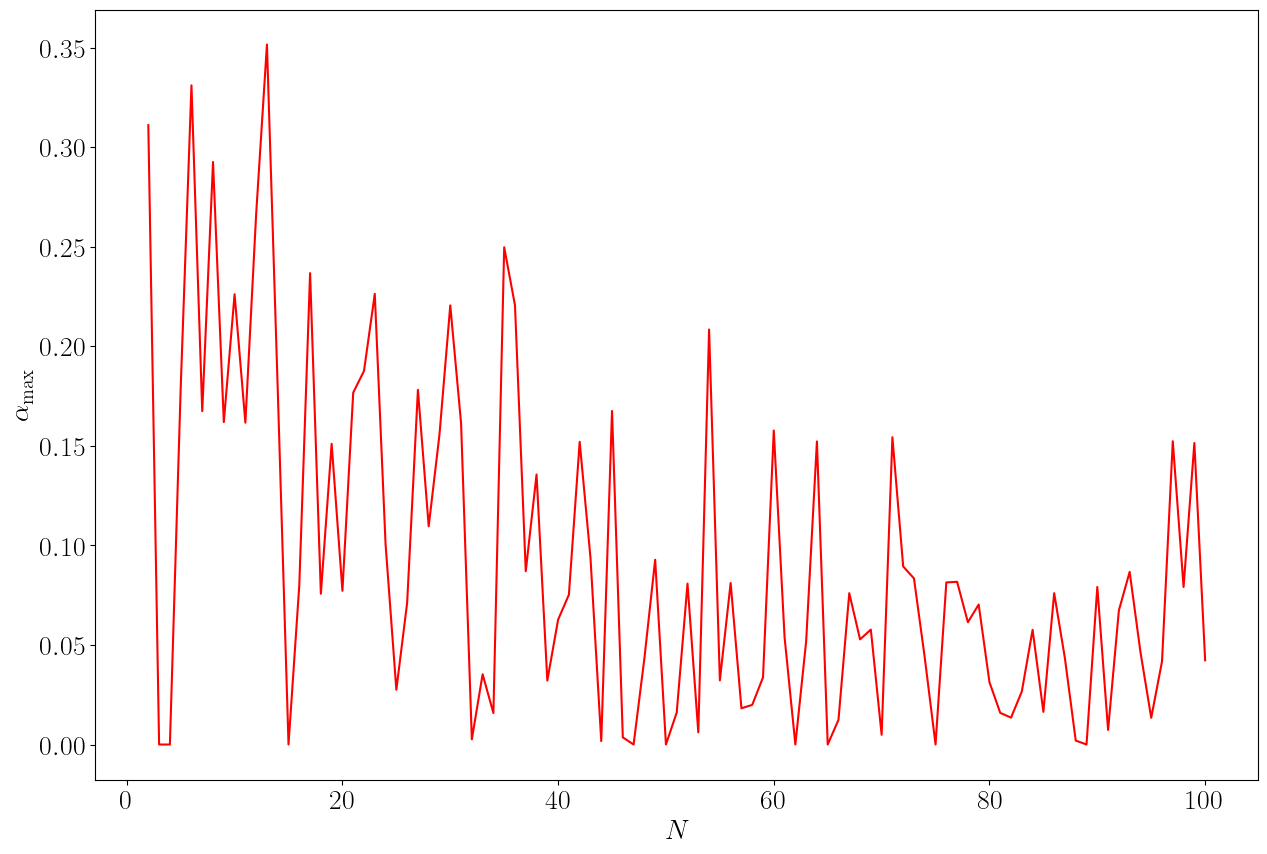

In [15]:
import functions
import importlib

importlib.reload(functions)
from functions import *

data = np.load("max_alp_data_100_nu3.npz")

max_alp_tot = data["max_alp_tot"]
max_alp_pop = data["max_alp_pop"]
max_alp_coh = data["max_alp_coh"]

N_vals = max_alp_tot[:, 1]
alp_tot = max_alp_tot[:, 0]
alp_pop = max_alp_pop[:, 0]
alp_coh = max_alp_coh[:, 0]

fig, ax = plt.subplots(figsize=(15, 10))

# ax.plot(N_vals, alp_tot, label='tot', color='purple')
ax.plot(N_vals, alp_pop, label='pop', color='r')
# ax.plot(N_vals, alp_coh, label='coh', color='b')

# ax.plot(N_vals, max_alp_tot, label='tot',color='purple') 
# ax.plot(N_vals, max_alp_pop, label="pop",color='r',) 
# ax.plot(N_vals, max_alp_coh, label="coh",color='b',)

ax.set_xlabel("$N$")
ax.set_ylabel(r"$\alpha_{\max}$")

# ax.legend()
plt.show()

Using to calculate ergo

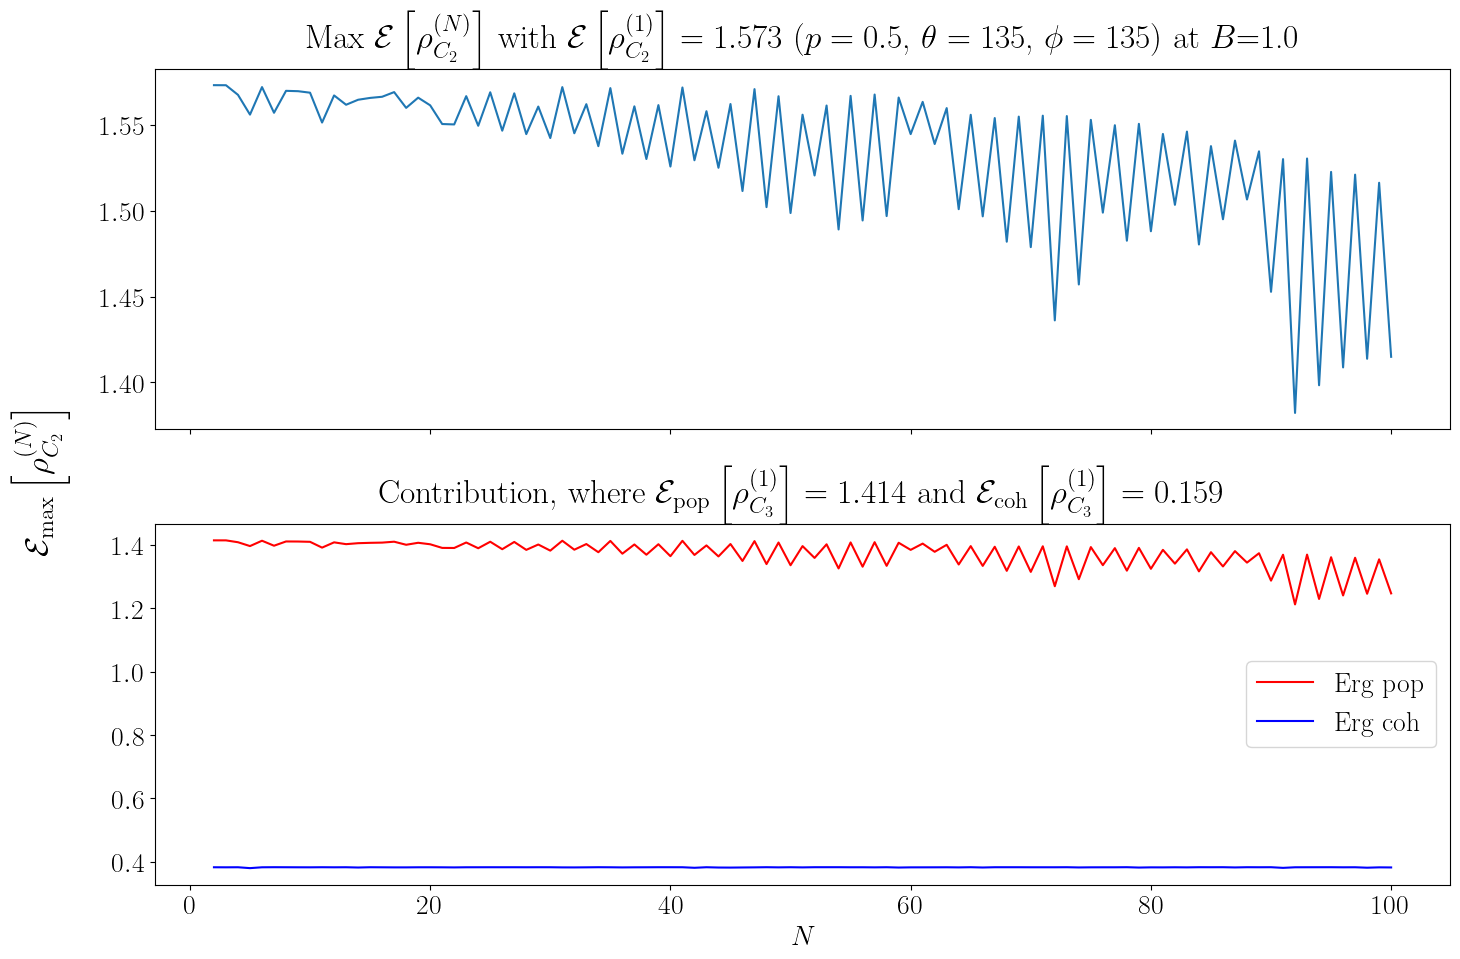

In [21]:
import functions
import importlib

importlib.reload(functions)
from functions import *

C = 1
a = 1
nu = 10
B = 1
p = 0.5
t_vals = np.linspace(0,1000, int(5 * 1e3))

Th = np.deg2rad(90+45)
Ph = np.deg2rad(90+45)

data = np.load("max_alp_data_100_nu10.npz")

max_alp_tot = data["max_alp_tot"]
max_alp_pop = data["max_alp_pop"]
max_alp_coh = data["max_alp_coh"]

N_vals = max_alp_tot[:, 1].astype(int)
alp_tot = max_alp_tot[:, 0]
alp_pop = max_alp_pop[:, 0]
alp_coh = max_alp_coh[:, 0]

Erg_in = B * (2 * np.sin(Th/2)**2-1+np.sqrt(1-4*p*(1-p)*np.sin(Th)**2 * np.sin(Ph)**2))
Erg_pop_in = 2*B * np.maximum(2*np.sin(Th/2)**2 - 1, 0)
Erg_coh_in = Erg_in - Erg_pop_in

fn_cl = np.sqrt(2)-1
Erg_tot_cl = B * (2 * np.sin(Th/2)**2*fn_cl**2-1+np.sqrt(1-4*fn_cl**2*(p*(1-p)*np.sin(Th)**2 * np.sin(Ph)**2+ np.sin(Th/2)**4*(1-fn_cl**2) ) ))

max_Erg_tot_all, max_Erg_pop_all, max_Erg_coh_all = Ergs_rhoC3_vs_N_var_alp(HxxDHLong, t_vals,N_vals, C, a, nu, B, alp_pop,p, Th, Ph)

fig, ax = plt.subplots(2, 1,sharex=True,figsize=(15, 10))

ax[0].plot(N_vals, max_Erg_tot_all, )
ax[1].plot(N_vals, max_Erg_pop_all, label=rf"Erg pop",color='r',)
ax[1].plot(N_vals, max_Erg_coh_all, label=rf"Erg coh",color='b',)

ax[0].set_title(rf"Max $\mathcal E \left[ \rho^{{(N)}}_{{C_2}} \right]$ with $\mathcal E \left[ \rho^{{(1)}}_{{C_2}} \right]= {Erg_in:.3f}$ $(p = {p}$, $\theta = {np.rad2deg(Th):.0f}$, $\phi = {np.rad2deg(Ph):.0f})$ at $B$={B:.1f}")
ax[1].set_title(rf"Contribution, where $\mathcal{{E}}_\mathrm{{pop}} \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_pop_in:.3f}$ and $\mathcal{{ E}}_\mathrm{{coh}} \left[ \rho^{{(1)}}_{{C_3}} \right]= {Erg_coh_in:.3f}$")


fig.supylabel(r"$\mathcal{ E}_\mathrm{max} \left[ \rho^{{(N)}}_{{C_2}} \right]$")
ax[1].set_xlabel("$N$")

ax[1].legend()

plt.tight_layout()
plt.savefig(f"Ergo_compare_E={Erg_in:.3f}.png")
# plt.close(fig)

done()